In [17]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
params = {
    'format': "json",
    "per_page": 200,
    "page": 1,
    "date": "2010:2024"
}

url = "https://api.worldbank.org/v2/country/CHL;PER;MAR;KOR;PHL/indicator/SP.POP.TOTL;SP.DYN.LE00.IN?source=2"

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
payload = response.json()


print("Metadata:",payload[0])
print("First item:", payload[1][0])
print(len(payload))
print(len(payload[1]))

Metadata: {'page': 1, 'pages': 1, 'per_page': 200, 'total': 150, 'sourceid': None, 'lastupdated': '2026-07-01'}
First item: {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'}, 'country': {'id': 'CL', 'value': 'Chile'}, 'countryiso3code': 'CHL', 'date': '2024', 'value': 19764771, 'unit': '', 'obs_status': '', 'decimal': 0}
2
150


In [13]:
data_pop = []
data_co2 = []
for year_val in payload[1]:
    #print(year_val)
    #'countryiso3code', 'date', 'value'ArithmeticError
    if year_val['indicator']['id'] == 'SP.POP.TOTL':
        data_pop.append({'ISO3':year_val['countryiso3code'], 'Population':year_val['value'], 'Year':year_val['date']})
    else:
        data_co2.append({'ISO3':year_val['countryiso3code'], 'CO2':year_val['value'], 'Year':year_val['date']})

#check first values
print(data_pop[0])
print(data_co2[0])



{'ISO3': 'CHL', 'Population': 19764771, 'Year': '2024'}
{'ISO3': 'CHL', 'CO2': 81.359, 'Year': '2024'}


In [14]:
#create dataframes
df_pop = pd.DataFrame(data_pop)
df_co2 = pd.DataFrame(data_co2)

#check for nulls
print(df_pop.isnull().sum())
print(df_co2.isnull().sum())

#check types
print(df_pop.dtypes)

#need to convert year to int
df_pop['Year'] = df_pop['Year'].astype(int)
df_co2['Year'] = df_co2['Year'].astype(int)

#check heads
print(df_pop.head(5))
print(df_co2.head(5))


ISO3          0
Population    0
Year          0
dtype: int64
ISO3    0
CO2     0
Year    0
dtype: int64
ISO3            str
Population    int64
Year            str
dtype: object
  ISO3  Population  Year
0  CHL    19764771  2024
1  CHL    19658835  2023
2  CHL    19553036  2022
3  CHL    19456334  2021
4  CHL    19370624  2020
  ISO3     CO2  Year
0  CHL  81.359  2024
1  CHL  81.167  2023
2  CHL  79.176  2022
3  CHL  78.876  2021
4  CHL  79.349  2020


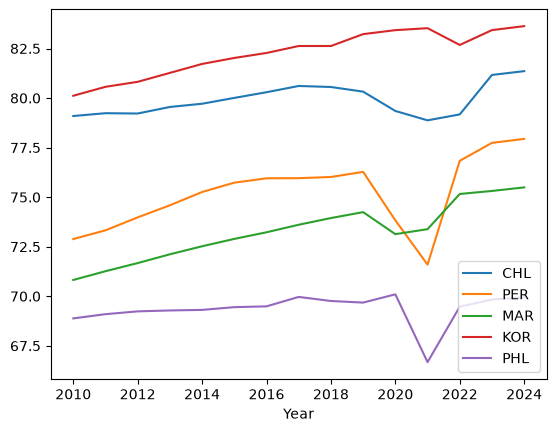

In [ ]:
#now plotting co2
df_co2_chl = df_co2[df_co2['ISO3'] == 'CHL']
df_co2_per = df_co2[df_co2['ISO3'] == 'PER']
df_co2_mar = df_co2[df_co2['ISO3'] == 'MAR']
df_co2_kor = df_co2[df_co2['ISO3'] == 'KOR']
df_co2_phl = df_co2[df_co2['ISO3'] == 'PHL']

fig, ax = plt.subplots()
df_co2_chl.plot(x='Year',y='CO2',ax=ax, label='CHL')
df_co2_per.plot(x='Year',y='CO2',ax=ax, label='PER')
df_co2_mar.plot(x='Year',y='CO2',ax=ax, label='MAR')
df_co2_kor.plot(x='Year',y='CO2',ax=ax, label='KOR')
df_co2_phl.plot(x='Year',y='CO2',ax=ax, label='PHL')

plt.show()


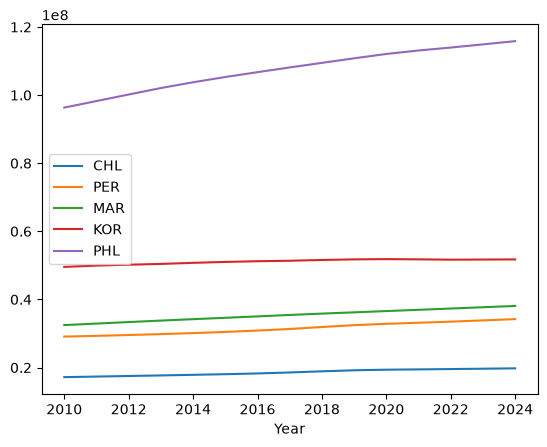

In [20]:
#now plotting pop
df_pop_chl = df_pop[df_pop['ISO3'] == 'CHL']
df_pop_per = df_pop[df_pop['ISO3'] == 'PER']
df_pop_mar = df_pop[df_pop['ISO3'] == 'MAR']
df_pop_kor = df_pop[df_pop['ISO3'] == 'KOR']
df_pop_phl = df_pop[df_pop['ISO3'] == 'PHL']

fig, ax = plt.subplots()
df_pop_chl.plot(x='Year',y='Population',ax=ax, label='CHL')
df_pop_per.plot(x='Year',y='Population',ax=ax, label='PER')
df_pop_mar.plot(x='Year',y='Population',ax=ax, label='MAR')
df_pop_kor.plot(x='Year',y='Population',ax=ax, label='KOR')
df_pop_phl.plot(x='Year',y='Population',ax=ax, label='PHL')

plt.show()

In [ ]:
#now need to compare the two indicators
target_year = 2019
